# VRPTW bằng Gurobi + Branch-and-Bound (dfs)

1. Xây mô hình MILP VRPTW.
2. Tại mỗi nút \(\omega\), giải **LP relaxation** bằng Gurobi
3. Cắt tỉa nếu LP vô nghiệm hoặc cận dưới không tốt hơn nghiệm hiện tại.
4. Nếu nghiệm LP nguyên, cập nhật nghiệm tốt nhất \(Z*\).
5. Nếu chưa nguyên, rẽ nhánh theo:
   - số xe rời depot,
   - biến cung phân số
6. Trực quan hóa depot, khách hàng và tuyến xe.

**Lưu ý quan trọng:** Gurobi direct MILP dùng để kiểm chứng. Manual B&B dùng để minh họa thuật toán

## 1. Import thư viện

In [94]:
import os
import math
import heapq
import itertools
from dataclasses import dataclass, field
from typing import Dict, Tuple, List, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import gurobipy as gp
    from gurobipy import GRB
except Exception as e:
    raise ImportError(
        "Chưa import được gurobipy. Cần cài Gurobi và kích hoạt license trước khi chạy notebook này."
    ) from e

## 2. Read Data

In [95]:

import os

DATA_PATH = "C101.txt"
if not os.path.exists(DATA_PATH) and os.path.exists("../data/C101.txt"):
    DATA_PATH = "../data/C101.txt"

MAX_CUSTOMERS = 9
EPS = 1e-6
TIME_LIMIT_PER_LP = 600000000        # giới hạn giây cho mỗi LP relaxation
MAX_NODES = 100000000

NODE_SELECTION = "dfs"        # "dfs" hoặc "best_bound"

# khởi tạo Z* = +inf,  heuristic = False
USE_INITIAL_HEURISTIC = False

print("DATA_PATH       =", DATA_PATH)
print("MAX_CUSTOMERS   =", MAX_CUSTOMERS)
print("NODE_SELECTION  =", NODE_SELECTION)
print("MAX_NODES       =", MAX_NODES)
print("USE_INITIAL_HEURISTIC =", USE_INITIAL_HEURISTIC)

DATA_PATH       = ../data/C101.txt
MAX_CUSTOMERS   = 9
NODE_SELECTION  = dfs
MAX_NODES       = 100000000
USE_INITIAL_HEURISTIC = False


In [96]:
def read_solomon_c101(path: str, max_customers: Optional[int] = None):
    """
    Đọc file Solomon VRPTW dạng C101.txt.

    Nếu max_customers != None:
        lấy depot + max_customers khách hàng đầu tiên.
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.rstrip("\n") for line in f]

    vehicle_number, capacity = None, None

    for idx, line in enumerate(lines):
        if "NUMBER" in line and "CAPACITY" in line:
            parts = lines[idx + 1].split()
            vehicle_number = int(parts[0])
            capacity = int(parts[1])
            break

    if vehicle_number is None or capacity is None:
        raise ValueError("Không đọc được NUMBER/CAPACITY trong file Solomon.")

    rows = []

    for line in lines:
        parts = line.split()

        if len(parts) == 7 and parts[0].lstrip("-").isdigit():
            rows.append([float(x) for x in parts])

    if not rows:
        raise ValueError("Không đọc được bảng CUSTOMER trong file Solomon.")

    df = pd.DataFrame(
        rows,
        columns=["cust_no", "x", "y", "demand", "ready", "due", "service"]
    )

    df["cust_no"] = df["cust_no"].astype(int)

    # ==============================
    # CẮT SỐ KHÁCH HÀNG Ở ĐÂY
    # ==============================
    if max_customers is not None:
        depot_df = df[df["cust_no"] == 0]
        customer_df = df[df["cust_no"] != 0].head(max_customers)

        df = pd.concat([depot_df, customer_df], ignore_index=True)

    return vehicle_number, capacity, df


vehicle_number, capacity, df = read_solomon_c101(DATA_PATH, MAX_CUSTOMERS)
print("Số xe tối đa m =", vehicle_number)
print("Sức chứa Q =", capacity)
print("Số node =", len(df), "; số khách hàng =", len(df) - 1)
display(df.head(10))

Số xe tối đa m = 25
Sức chứa Q = 200
Số node = 10 ; số khách hàng = 9


,cust_no,x,y,demand,ready,due,service
0,0,40.0,50.0,0.0,0.0,1236.0,0.0
1,1,45.0,68.0,10.0,912.0,967.0,90.0
2,2,45.0,70.0,30.0,825.0,870.0,90.0
3,3,42.0,66.0,10.0,65.0,146.0,90.0
4,4,42.0,68.0,10.0,727.0,782.0,90.0
5,5,42.0,65.0,10.0,15.0,67.0,90.0
6,6,40.0,69.0,20.0,621.0,702.0,90.0
7,7,40.0,66.0,20.0,170.0,225.0,90.0
8,8,38.0,68.0,20.0,255.0,324.0,90.0
9,9,38.0,70.0,10.0,534.0,605.0,90.0


## 3. Tập hợp, tham số bài toán vrptw

In [97]:
def build_vrptw_data(df: pd.DataFrame, vehicle_number: int, capacity: float):
    df = df.copy().reset_index(drop=True)
    nodes = [int(v) for v in df["cust_no"].tolist()]
    depot = 0
    customers = [i for i in nodes if i != depot]

    xcoord = dict(zip(df["cust_no"].astype(int), df["x"].astype(float)))
    ycoord = dict(zip(df["cust_no"].astype(int), df["y"].astype(float)))
    q = dict(zip(df["cust_no"].astype(int), df["demand"].astype(float)))
    a = dict(zip(df["cust_no"].astype(int), df["ready"].astype(float)))
    b = dict(zip(df["cust_no"].astype(int), df["due"].astype(float)))
    service = dict(zip(df["cust_no"].astype(int), df["service"].astype(float)))

    arcs = [(i, j) for i in nodes for j in nodes if i != j]

    c = {} # khoang cach Euclid giua i va j
    tau = {} # thoi gian phuc vu tai i + thoi gian di chuyen i -> j
    M_time = {}
    for i, j in arcs:
        dist = math.hypot(xcoord[i] - xcoord[j], ycoord[i] - ycoord[j])
        c[i, j] = dist
        tau[i, j] = service[i] + dist
        # Big-M cho time link tới khách hàng j.
        M_time[i, j] = max(0.0, b[i] + tau[i, j] - a[j])

    data = {
        "df": df,
        "nodes": nodes,
        "customers": customers,
        "depot": depot,
        "arcs": arcs,
        "m": int(vehicle_number),
        "Q": float(capacity),
        "xcoord": xcoord,
        "ycoord": ycoord,
        "q": q,
        "a": a,
        "b": b,
        "service": service,
        "c": c,
        "tau": tau,
        "M_time": M_time,
    }
    return data

In [98]:
data = build_vrptw_data(df, vehicle_number, capacity)
print("|I (customers)| =", len(data["customers"]))
print("|I0 (depot + customers)| =", len(data["nodes"]))
print("Số cung (x_ij) =", len(data["arcs"]))

|I (customers)| = 9
|I0 (depot + customers)| = 10
Số cung (x_ij) = 90


## 4. Cấu trúc node

In [99]:
@dataclass
class BBNode:
    depth: int = 0
    fixed_arcs: Dict[Tuple[int, int], int] = field(default_factory=dict)
    vehicle_lb: int = 0
    vehicle_ub: Optional[int] = None
    time_bounds: Dict[int, Tuple[float, float]] = field(default_factory=dict)
    note: str = "root"


def clone_node(parent: BBNode, note: str = "child") -> BBNode:
    return BBNode(
        depth=parent.depth + 1,
        # luu cac cung rẽ nhánh
        fixed_arcs=dict(parent.fixed_arcs),
        vehicle_lb=parent.vehicle_lb,
        vehicle_ub=parent.vehicle_ub,
        time_bounds=dict(parent.time_bounds),
        note=note,
    )

## 5. Xây dựng model VRPTW bằng Gurobi


Hàm dưới đây dùng chung cho:

- LP relaxation tại mỗi node B&B: `relax=True`.
- MILP kiểm chứng trực tiếp: `relax=False`.

Các ràng buộc:
- mỗi khách hàng có đúng một cung rời đi,
- bảo toàn luồng tại khách hàng,
- số xe xuất phát từ depot không vượt quá (m),
- liên kết thời gian,
- liên kết tải trọng,
- cửa sổ thời gian,
- sức chứa.

In [100]:

def build_gurobi_vrptw_model(
    data: Dict[str, Any],
    node: Optional[BBNode] = None,
    relax: bool = True,
    name: str = "VRPTW",
    time_limit: Optional[float] = None,
    output_flag: int = 0,
):
    nodes = data["nodes"]
    customers = data["customers"]
    depot = data["depot"]
    arcs = data["arcs"]
    c = data["c"]
    tau = data["tau"]
    M_time = data["M_time"]
    q = data["q"]
    a = data["a"]
    b = data["b"]
    Q = data["Q"]
    m = data["m"]

    model = gp.Model(name)
    model.Params.OutputFlag = output_flag
    if time_limit is not None:
        model.Params.TimeLimit = time_limit

    # x_ij: LP relaxation
    x_vtype = GRB.CONTINUOUS if relax else GRB.BINARY
    x = model.addVars(arcs, lb=0.0, ub=1.0, vtype=x_vtype, name="x")

    # t_i: thời điểm bắt đầu phục vụ tại i
    t = model.addVars(nodes, lb=0.0, vtype=GRB.CONTINUOUS, name="t")

    # y_i: tải trọng tích lũy sau khi phục vụ/rời khỏi i
    y = model.addVars(nodes, lb=0.0, ub=Q, vtype=GRB.CONTINUOUS, name="y")

    # Objective: hàm mục tiêu
    model.setObjective(gp.quicksum(c[i, j] * x[i, j] for i, j in arcs), GRB.MINIMIZE)

    # R1: mỗi khách hàng có đúng một cung rời đi
    for i in customers:
        model.addConstr(
            gp.quicksum(x[i, j] for j in nodes if j != i) == 1,
            name=f"R1_out_once_{i}"
        )

    # R2: bảo toàn luồng tại mỗi khách hàng
    for i in customers:
        model.addConstr(
            gp.quicksum(x[i, j] for j in nodes if j != i)
            - gp.quicksum(x[j, i] for j in nodes if j != i)
            == 0,
            name=f"R2_flow_{i}"
        )

    # R3: giới hạn số xe rời depot
    vehicle_count = gp.quicksum(x[depot, j] for j in customers)
    model.addConstr(vehicle_count <= m, name="R3_vehicle_ub_m")

    # R4: liên kết thời gian.
    for i in nodes:
        for j in customers:
            if i == j:
                continue
            model.addConstr(
                t[j] >= t[i] + tau[i, j] - M_time[i, j] * (1 - x[i, j]),
                name=f"R4_time_{i}_{j}"
            )

    # R5: liên kết tải trọng.
    for i in nodes:
        for j in customers:
            if i == j:
                continue
            model.addConstr(
                y[j] >= y[i] + q[j] - Q * (1 - x[i, j]),
                name=f"R5_load_{i}_{j}"
            )

    # R6: cửa sổ thời gian
    for i in nodes:
        lb = a[i]
        ub = b[i]
        if node is not None and i in node.time_bounds:
            lb = max(lb, node.time_bounds[i][0])
            ub = min(ub, node.time_bounds[i][1])
        model.addConstr(t[i] >= lb, name=f"R6_time_lb_{i}")
        model.addConstr(t[i] <= ub, name=f"R6_time_ub_{i}")

    # Depot bắt đầu
    model.addConstr(t[depot] == a[depot], name="depot_start_time")
    model.addConstr(y[depot] == 0, name="depot_start_load")

    # Ràng buộc bổ sung từ node B&B
    if node is not None:
        # fixed x_ij = 0 hoặc 1
        for (i, j), val in node.fixed_arcs.items():
            if (i, j) in x:
                model.addConstr(x[i, j] == int(val), name=f"branch_x_{i}_{j}_{val}")

        # branch theo số xe
        if node.vehicle_lb is not None:
            model.addConstr(vehicle_count >= node.vehicle_lb, name="branch_vehicle_lb")
        if node.vehicle_ub is not None:
            model.addConstr(vehicle_count <= node.vehicle_ub, name="branch_vehicle_ub")

    model.update()
    return model, x, t, y

## 5. Hàm truy vết tuyến đường

In [101]:

def get_solution_values(x, t, y):
    x_sol = {key: var.X for key, var in x.items()}
    t_sol = {key: var.X for key, var in t.items()}
    y_sol = {key: var.X for key, var in y.items()}
    return x_sol, t_sol, y_sol

def is_binary_value(v: float, eps: float = EPS) -> bool:
    return abs(v) <= eps or abs(v - 1.0) <= eps

def is_integral_x(x_sol: Dict[Tuple[int, int], float], eps: float = EPS) -> bool:
    return all(is_binary_value(v, eps) for v in x_sol.values())

def selected_arcs_from_x(x_sol: Dict[Tuple[int, int], float], eps: float = EPS):
    return [(i, j) for (i, j), val in x_sol.items() if val >= 1.0 - eps]


def extract_routes_from_x(data: Dict[str, Any], x_sol: Dict[Tuple[int, int], float], eps: float = EPS):
    """
    Truy vết tuyến từ nghiệm nguyên x_ij.
    """
    depot = data["depot"]
    customers = set(data["customers"])
    arcs = selected_arcs_from_x(x_sol, eps)

    next_map = {}
    for i, j in arcs:
        if i in next_map:
            pass
        next_map[i] = j

    starts = [j for (i, j) in arcs if i == depot and j != depot]
    routes = []
    visited_customers = set()

    for start in starts:
        route = [depot]
        current = start
        safety = 0

        while True:
            route.append(current)
            if current == depot:
                break

            if current in visited_customers:
                route.append("LOOP")
                break
            visited_customers.add(current)

            if current not in next_map:
                route.append("DEAD_END")
                break

            current = next_map[current]
            safety += 1
            if safety > len(customers) + 2:
                route.append("LOOP")
                break

        routes.append(route)

    missing = sorted(customers - visited_customers)
    return routes, missing

# tong suc chua cua mot chuyen
def route_load(data: Dict[str, Any], route: List[int]) -> float:
    q = data["q"]
    total = 0.0
    for node in route:
        if isinstance(node, int) and node != data["depot"]:
            total += q[node]
    return total

# tong quang duong
def route_distance(data: Dict[str, Any], route: List[int]) -> float:
    c = data["c"]
    total = 0.0
    clean_route = [node for node in route if isinstance(node, int)]
    for i, j in zip(clean_route[:-1], clean_route[1:]):
        total += c[i, j]
    return total

def validate_integral_solution(data: Dict[str, Any], x_sol, t_sol=None, y_sol=None, eps: float = EPS):
    """
    Kiểm tra nghiệm nguyên tạo được tuyến đầy đủ hay không.
    """
    customers = data["customers"]
    nodes = data["nodes"]
    depot = data["depot"]
    Q = data["Q"]

    # outgoing/incoming từng khách hàng
    for i in customers:
        out_sum = sum(1 for j in nodes if j != i and x_sol.get((i, j), 0.0) >= 1 - eps)
        in_sum = sum(1 for j in nodes if j != i and x_sol.get((j, i), 0.0) >= 1 - eps)
        if out_sum != 1 or in_sum != 1:
            return False, [], f"Customer {i} has out={out_sum}, in={in_sum}"

    routes, missing = extract_routes_from_x(data, x_sol, eps)
    if missing:
        return False, routes, f"Missing customers not connected from depot: {missing}"

    for r in routes:
        if not r or r[0] != depot or r[-1] != depot:
            return False, routes, f"Route does not start/end at depot: {r}"
        if route_load(data, r) > Q + eps:
            return False, routes, f"Capacity violation route {r}"

    return True, routes, "OK"


## 6. Giải LP relaxation tại một node

In [102]:

def solve_lp_relaxation_at_node(data: Dict[str, Any], node: BBNode):
    model, x, t, y = build_gurobi_vrptw_model(
        data=data,
        node=node,
        relax=True,
        name=f"LP_node_depth_{node.depth}",
        time_limit=TIME_LIMIT_PER_LP,
        output_flag=0,
    )
    model.optimize()

    if model.Status in [GRB.INFEASIBLE, GRB.INF_OR_UNBD, GRB.UNBOUNDED]:
        return {
            "status": model.Status,
            "feasible": False,
            "reason": "LP infeasible/unbounded",
            "node": node,
        }

    if model.SolCount == 0:
        return {
            "status": model.Status,
            "feasible": False,
            "reason": "No LP solution found",
            "node": node,
        }

    x_sol, t_sol, y_sol = get_solution_values(x, t, y)
    return {
        "status": model.Status,
        "feasible": True, # trang thai: node co nghiem LP kha thi
        "obj": float(model.ObjVal), # gia tri ham muc tieu
        "x": x_sol,
        "t": t_sol,
        "y": y_sol,
        "node": node,
    }

## 7. Rẽ nhánh

In [103]:
def fractional_part(v: float) -> float:
    return abs(v - round(v))

def is_integer_like(v: float, eps: float = EPS) -> bool:
    return abs(v - round(v)) <= eps

def choose_fractional_arc(x_sol: Dict[Tuple[int, int], float], eps: float = EPS):
    """Chọn x_uv phân số gần 0.5 nhất."""
    candidates = []
    for (i, j), val in x_sol.items(): # duyet toan bo nghiem xij trong (0,1)
        if eps < val < 1.0 - eps:
            candidates.append((abs(val - 0.5), i, j, val))
    if not candidates:
        return None
    candidates.sort(key=lambda item: item[0])
    _, i, j, val = candidates[0]
    return i, j, val

# branch
def branch_node(data: Dict[str, Any], lp_result: Dict[str, Any]):
    node = lp_result["node"]
    x_sol = lp_result["x"]
    depot = data["depot"]
    customers = data["customers"]
    m = data["m"]

    children = []

    # Chiến lược 1: rẽ nhánh trên số lượng xe
    l_val = sum(x_sol[depot, j] for j in customers)
    # neu so xe khong nguyen
    if not is_integer_like(l_val):
        low = math.floor(l_val)
        high = math.ceil(l_val)

        child_le = clone_node(node, note=f"vehicle <= {low}")
        child_le.vehicle_ub = low if child_le.vehicle_ub is None else min(child_le.vehicle_ub, low)

        child_ge = clone_node(node, note=f"vehicle >= {high}")
        child_ge.vehicle_lb = max(child_ge.vehicle_lb, high)
        if child_ge.vehicle_ub is None:
            child_ge.vehicle_ub = m

        children = [child_le, child_ge]
        return children, f"Branch vehicle count l={l_val:.6f}"

    # Chiến lược 2: rẽ nhánh trên biến luồng x_uv
    arc_choice = choose_fractional_arc(x_sol)
    if arc_choice is None:
        return [], "No fractional arc found"

    u, v, val = arc_choice

    child_zero = clone_node(node, note=f"x_{u}_{v}=0")
    child_zero.fixed_arcs[u, v] = 0

    child_one = clone_node(node, note=f"x_{u}_{v}=1")
    child_one.fixed_arcs[u, v] = 1

    children = [child_zero, child_one]
    return children, f"Branch arc x[{u},{v}]={val:.6f}"

## 8. Giai MILP bang Gurobi

In [104]:

def solve_direct_milp_for_check(data: Dict[str, Any], time_limit: float = 5000):
    model, x, t, y = build_gurobi_vrptw_model(
        data=data,
        node=BBNode(depth=0, vehicle_lb=0, vehicle_ub=data["m"], note="direct_milp"),
        relax=False,
        name="VRPTW_Direct_MILP_Check",
        time_limit=time_limit,
        output_flag=1,
    )
    model.optimize()

    if model.SolCount == 0:
        return {
            "status": model.Status,
            "has_solution": False,
            "obj": math.inf,
            "routes": [],
            "model": model,
        }

    x_sol, t_sol, y_sol = get_solution_values(x, t, y)
    ok, routes, msg = validate_integral_solution(data, x_sol, t_sol, y_sol)

    return {
        "status": model.Status,
        "has_solution": True,
        "obj": float(model.ObjVal),
        "mip_gap": getattr(model, "MIPGap", None),
        "x": x_sol,
        "t": t_sol,
        "y": y_sol,
        "routes": routes,
        "valid": ok,
        "message": msg,
        "model": model,
    }

## 9. Branch and Bound

In [105]:

def manual_branch_and_bound_vrptw(data):
    root = BBNode(
        depth=0,
        vehicle_lb=0,
        vehicle_ub=data["m"],
        note="root"
    )

    best_obj = math.inf
    best_solution = None

    stats = {
        "nodes_solved": 0, # so node da duoc giai lp relaxation
        "nodes_popped": 0, # so node da duoc lay ra khoi hang doi
        "lp_infeasible": 0, # so node ma lp vo nghiem
        "pruned_by_bound": 0, # so node bi cat
        "integer_solutions": 0, # so nghiem nguyen kha thi tim duoc
        "branch_count": 0, # so lan thuat toan re nhanh
        "max_depth": 0, # do sau lon nhat cua cay
        "log": [], # danh sach qua trinh chay
    }

    counter = itertools.count()
    omega = [] # tap cac not dang cho xet
    # them node vao danh sach cho
    def add_frontier(lp_result):
        if NODE_SELECTION == "dfs":
            omega.append(lp_result)
        else:
            heapq.heappush(omega, (lp_result["obj"], next(counter), lp_result))
    # lay node ra
    def pop_frontier():
        if NODE_SELECTION == "dfs":
            return omega.pop()
        else:
            return heapq.heappop(omega)[2]
    # dem so node con lai
    def frontier_size():
        return len(omega)

    def evaluate_node(node):
        """Giai LP, cat tia, hoac tra ve lp_result de branch."""
        nonlocal best_obj, best_solution

        stats["nodes_solved"] += 1
        stats["max_depth"] = max(stats["max_depth"], node.depth)

        lp = solve_lp_relaxation_at_node(data, node)

        if stats["nodes_solved"] <= 20 or stats["nodes_solved"] % 500 == 0:
            print(
                f"Solved node #{stats['nodes_solved']} | "
                f"depth={node.depth} | feasible={lp['feasible']} | "
                f"best={best_obj:.4f}",
                flush=True
        )

        # Cat tia: vo nghiem
        if not lp["feasible"]:
            stats["lp_infeasible"] += 1
            return None

        bound = lp["obj"]

        # Cat tia: can duoi khong cai thien incumbent
        if bound >= best_obj - EPS:
            stats["pruned_by_bound"] += 1
            return None

        # Nghiem nguyen
        if is_integral_x(lp["x"]):
            ok, routes, msg = validate_integral_solution(data, lp["x"], lp["t"], lp["y"])
            if ok and bound < best_obj - EPS:
                best_obj = bound
                best_solution = {
                    "obj": bound,
                    "x": lp["x"],
                    "t": lp["t"],
                    "y": lp["y"],
                    "routes": routes,
                    "depth": node.depth,
                    "source": "manual_bnb_integer_lp",
                }
                stats["integer_solutions"] += 1
                log_msg = (
                    f"New incumbent: obj={best_obj:.4f}, "
                    f"depth={node.depth}, routes={len(routes)}"
                )
                stats["log"].append(log_msg)
                print(log_msg, flush=True)
            else:
                stats["log"].append(f"Integral LP but validation failed: {msg}")
            return None  # khong can branch

        # Chua nguyen, can branch
        return lp

    # Z* = +inf.
    # USE_INITIAL_HEURISTIC=True chạy solve_direct_milp_for_check tim no heuristic
    if USE_INITIAL_HEURISTIC:
        print("Dang chay heuristic warm-start (time limit 30s)...")
        h = solve_direct_milp_for_check(data, time_limit=30)
        if h["has_solution"] and h["obj"] < best_obj - EPS:
            best_obj = h["obj"]
            best_solution = {
                "obj": best_obj,
                "x": h["x"],
                "t": h["t"],
                "y": h["y"],
                "routes": h["routes"],
                "depth": 0,
                "source": "heuristic_warmstart",
            }
            stats["integer_solutions"] += 1
            stats["log"].append(f"Heuristic incumbent: obj={best_obj:.4f}")
            print(f"  Heuristic incumbent = {best_obj:.4f}")
        else:
            print("  Heuristic khong tim duoc nghiem, tiep tuc khong co incumbent.")

    # Danh gia root
    lp_root = evaluate_node(root)
    if lp_root is not None:
        add_frontier(lp_root)

    while frontier_size() > 0 and stats["nodes_solved"] < MAX_NODES:
        current_lp = pop_frontier()
        stats["nodes_popped"] += 1
        node = current_lp["node"]
        bound = current_lp["obj"]

        if bound >= best_obj - EPS:
            stats["pruned_by_bound"] += 1
            continue

        # neu node bi cat chua nguyen, tao 2 nhanh con
        children, branch_msg = branch_node(data, current_lp)
        stats["branch_count"] += 1

        if stats["branch_count"] <= 20 or stats["branch_count"] % 500 == 0:
            log_msg = (
                f"Branch #{stats['branch_count']}: depth={node.depth}, "
                f"bound={bound:.4f}, best={best_obj:.4f}, {branch_msg}, "
                f"frontier={frontier_size()}, solved={stats['nodes_solved']}"
            )
            stats["log"].append(log_msg)
            print(log_msg, flush=True)

        for child in children:
            # Loc nhanh: vehicle bounds vo ly
            if child.vehicle_ub is not None and child.vehicle_lb > child.vehicle_ub:
                continue
            # Loc nhanh: time bounds vo ly
            if any(lb > ub + EPS for lb, ub in child.time_bounds.values()):
                continue
            # FIX: kiem tra node limit truoc khi giai LP con
            if stats["nodes_solved"] >= MAX_NODES:
                break

            lp_child = evaluate_node(child)
            if lp_child is not None:
                add_frontier(lp_child)

    # Toi uu khi queue rong (khong bi cat boi MAX_NODES)
    stopped_by_limit = stats["nodes_solved"] >= MAX_NODES and frontier_size() > 0
    optimal_proved = not stopped_by_limit

    return {
        "best_obj": best_obj,
        "best_solution": best_solution,
        "optimal_proved": optimal_proved,
        "stopped_by_node_limit": stopped_by_limit,
        "remaining_nodes": frontier_size(),
        "stats": stats,
    }


## 10. Run Branch and Bound

In [106]:
bnb_result = manual_branch_and_bound_vrptw(data)

print("========== MANUAL B&B RESULT ==========")
print("best_obj          =", bnb_result["best_obj"])
print("has_solution      =", bnb_result["best_solution"] is not None)
print("optimal_proved    =", bnb_result["optimal_proved"]) # false: tốt nhất hiện tại, chưa chắc tối ưu
print("stopped_node_limit=", bnb_result["stopped_by_node_limit"])
print("remaining_nodes   =", bnb_result["remaining_nodes"]) # so node con lại khi thuật toán dừng
print("stats:")
for k, v in bnb_result["stats"].items():
    if k != "log":
        print(f"  {k}: {v}")

print("\nLog gan nhat:")
for line in bnb_result["stats"]["log"][-20:]:
    print(" -", line)

if bnb_result["best_solution"] is not None:
    src = bnb_result["best_solution"].get("source", "")
    print(f"\nNguon nghiem: {src}")
    print("\nTuyến xe từ B&B:")
    for idx, route in enumerate(bnb_result["best_solution"]["routes"], start=1):
        print(f"Route {idx}:", " -> ".join(map(str, route)))
else:
    print("\nManual B&B chua tim duoc nghiem nguyen trong gioi han node hien tai.")


Solved node #1 | depth=0 | feasible=True | best=inf
Branch #1: depth=0, bound=21.5634, best=inf, Branch arc x[5,3]=0.526770, frontier=0, solved=1
Solved node #2 | depth=1 | feasible=True | best=inf
Solved node #3 | depth=1 | feasible=True | best=inf
Branch #2: depth=1, bound=23.2195, best=inf, Branch arc x[6,4]=0.442415, frontier=1, solved=3
Solved node #4 | depth=2 | feasible=True | best=inf
Solved node #5 | depth=2 | feasible=True | best=inf
Branch #3: depth=2, bound=26.6889, best=inf, Branch vehicle count l=0.063546, frontier=2, solved=5
Solved node #6 | depth=3 | feasible=True | best=inf
Solved node #7 | depth=3 | feasible=True | best=inf
Branch #4: depth=3, bound=50.5367, best=inf, Branch arc x[1,0]=0.683258, frontier=3, solved=7
Solved node #8 | depth=4 | feasible=True | best=inf
Solved node #9 | depth=4 | feasible=True | best=inf
Branch #5: depth=4, bound=51.6761, best=inf, Branch arc x[7,6]=0.316742, frontier=4, solved=9
Solved node #10 | depth=5 | feasible=True | best=inf
Solv

## 11. Gurobi giải  trực tiếp mô hình

In [107]:
milp_check = solve_direct_milp_for_check(data, time_limit=3000)

print("========== GUROBI DIRECT MILP ==========")
print("status       =", milp_check["status"])
print("has_solution =", milp_check["has_solution"])
print("obj          =", milp_check["obj"])
print("valid        =", milp_check.get("valid"))
print("message      =", milp_check.get("message"))

if milp_check["has_solution"]:
    print("\nTuyến xe từ Gurobi direct:")
    for idx, route in enumerate(milp_check["routes"], start=1):
        print(f"Route {idx}:", " -> ".join(map(str, route)))

Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 3000
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-12400F, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  3000

Optimize a model with 205 rows, 110 columns and 749 nonzeros (Min)
Model fingerprint: 0x78154198
Model has 90 linear objective coefficients
Variable types: 20 continuous, 90 integer (90 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 2e+02]
  RHS range        [1e+00, 1e+03]

Found heuristic solution: objective 229.7676863
Presolve removed 205 rows and 110 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 12 available processors)

Solution coun

## 12. Trực quan hóa

In [108]:
def summarize_routes(data: Dict[str, Any], routes: List[List[int]]):
    rows = []
    for idx, route in enumerate(routes, start=1):
        clean_route = [node for node in route if isinstance(node, int)]
        customers_in_route = [node for node in clean_route if node != data["depot"]]
        rows.append({
            "route_id": idx,
            "route": " -> ".join(map(str, clean_route)),
            "num_customers": len(customers_in_route),
            "load": route_load(data, clean_route),
            "distance": route_distance(data, clean_route),
        })
    return pd.DataFrame(rows)


def plot_locations(data: Dict[str, Any], title: str = "Vị trí depot và khách hàng"):
    df_plot = data["df"]
    depot = data["depot"]

    depot_df = df_plot[df_plot["cust_no"] == depot]
    cust_df = df_plot[df_plot["cust_no"] != depot]

    plt.figure(figsize=(9, 7))
    plt.scatter(cust_df["x"], cust_df["y"], s=45, label="Khách hàng")
    plt.scatter(depot_df["x"], depot_df["y"], s=160, marker="s", label="Depot")

    for _, row in df_plot.iterrows():
        plt.text(row["x"] + 0.5, row["y"] + 0.5, str(int(row["cust_no"])), fontsize=9)

    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

#plot_locations(data)

In [109]:
def plot_routes(data: Dict[str, Any], routes: List[List[int]], title: str = "Tuyến xe VRPTW"):
    df_plot = data["df"]
    depot = data["depot"]
    coord = {
        int(row["cust_no"]): (float(row["x"]), float(row["y"]))
        for _, row in df_plot.iterrows()
    }

    depot_df = df_plot[df_plot["cust_no"] == depot]
    cust_df = df_plot[df_plot["cust_no"] != depot]

    plt.figure(figsize=(11, 8))

    # Vẽ node
    plt.scatter(cust_df["x"], cust_df["y"], s=45, label="Khách hàng")
    plt.scatter(depot_df["x"], depot_df["y"], s=170, marker="s", label="Depot")

    # Label node
    for _, row in df_plot.iterrows():
        plt.text(row["x"] + 0.5, row["y"] + 0.5, str(int(row["cust_no"])), fontsize=9)

    # Vẽ tuyến
    for k, route in enumerate(routes, start=1):
        clean_route = [node for node in route if isinstance(node, int)]
        if len(clean_route) < 2:
            continue

        xs = [coord[node][0] for node in clean_route]
        ys = [coord[node][1] for node in clean_route]
        load = route_load(data, clean_route)

        plt.plot(xs, ys, marker="o", linewidth=1.8, label=f"Route {k} | load={load:.0f}")

        # Mũi tên hướng đi
        for u, v in zip(clean_route[:-1], clean_route[1:]):
            x1, y1 = coord[u]
            x2, y2 = coord[v]
            plt.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.1, shrinkA=5, shrinkB=5),
            )

    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(title)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()

### 12.1 Branch and Bound

Summary routes - Manual B&B


,route_id,route,num_customers,load,distance
0,1,0 -> 5 -> 3 -> 7 -> 8 -> 9 -> 6 -> 4 -> 2 -> 1...,9,140.0,51.720402


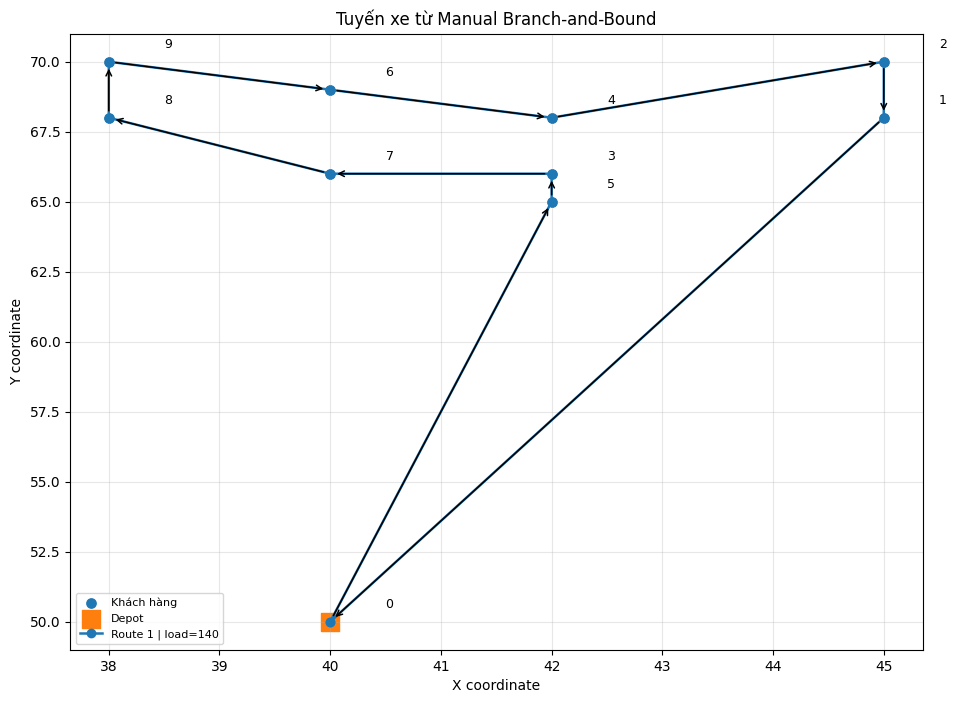

In [110]:
if bnb_result["best_solution"] is not None:
    routes_bnb = bnb_result["best_solution"]["routes"]
    print("Summary routes - Manual B&B")
    display(summarize_routes(data, routes_bnb))
    plot_routes(data, routes_bnb, title="Tuyến xe từ Manual Branch-and-Bound")
else:
    print("Manual B&B chưa có nghiệm để vẽ. Hãy tăng MAX_NODES hoặc giảm MAX_CUSTOMERS để minh họa.")

### 12.2 Gurobi

Summary routes - Gurobi direct MILP


,route_id,route,num_customers,load,distance
0,1,0 -> 5 -> 3 -> 7 -> 8 -> 9 -> 6 -> 4 -> 2 -> 1...,9,140.0,51.720402


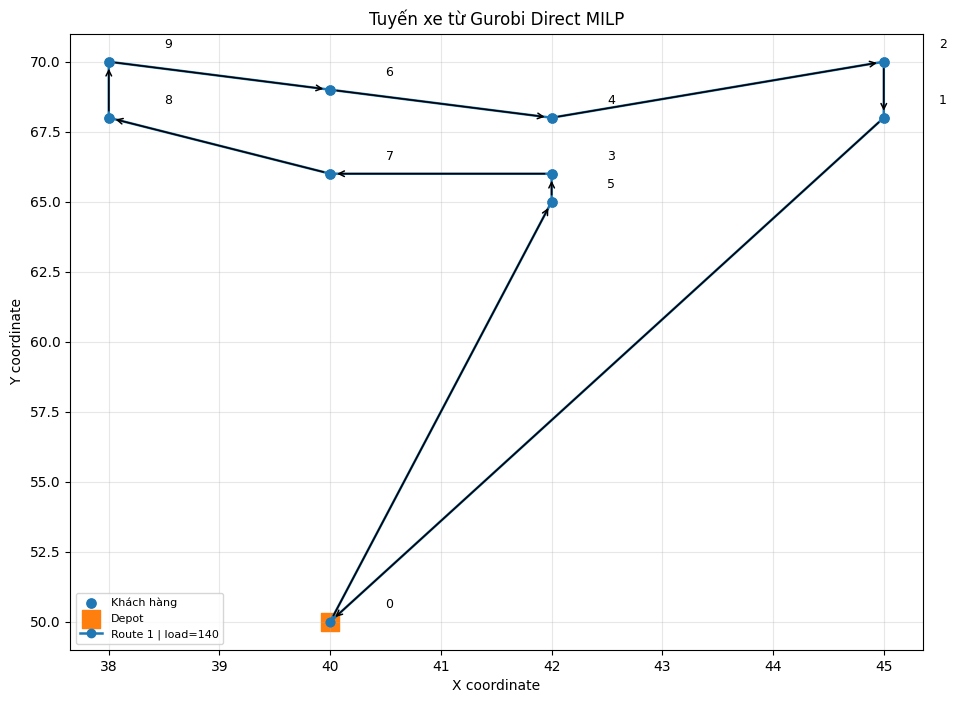

In [111]:
if milp_check["has_solution"]:
    routes_milp = milp_check["routes"]
    print("Summary routes - Gurobi direct MILP")
    display(summarize_routes(data, routes_milp))
    plot_routes(data, routes_milp, title="Tuyến xe từ Gurobi Direct MILP")
else:
    print("Gurobi direct MILP chưa có nghiệm để vẽ.")

## 13. So sánh

In [112]:
compare_rows = []

compare_rows.append({
    "method": "Manual B&B",
    "has_solution": bnb_result["best_solution"] is not None,
    "objective": bnb_result["best_obj"] if bnb_result["best_solution"] is not None else None,
    "optimal_proved": bnb_result["optimal_proved"],
    "nodes_solved": bnb_result["stats"]["nodes_solved"],
    "remaining_nodes": bnb_result["remaining_nodes"],
})

compare_rows.append({
    "method": "Gurobi direct MILP",
    "has_solution": milp_check["has_solution"],
    "objective": milp_check["obj"] if milp_check["has_solution"] else None,
    "optimal_proved": milp_check["status"] == GRB.OPTIMAL,
    "nodes_solved": None,
    "remaining_nodes": None,
})

compare_df = pd.DataFrame(compare_rows)
display(compare_df)

if bnb_result["best_solution"] is not None and milp_check["has_solution"]:
    if not bnb_result["optimal_proved"]:
        print(
            "không được xem là nghiệm tối ưu cuối cùng."
        )

,method,has_solution,objective,optimal_proved,nodes_solved,remaining_nodes
0,Manual B&B,True,51.720402,True,535.0,0.0
1,Gurobi direct MILP,True,51.720402,True,NaN,NaN
